<a href="https://colab.research.google.com/github/mmjtech20-pixel/MLT-Practicals/blob/main/tennis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Play Tennis dataset
data = {
    'day': ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7',
            'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14'],

    'outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain',
                'Rain', 'Rain', 'Overcast', 'Sunny',
                'Sunny', 'Rain', 'Sunny', 'Overcast',
                'Overcast', 'Rain'],

    'temp': ['Hot', 'Hot', 'Hot', 'Mild',
             'Cool', 'Cool', 'Cool', 'Mild',
             'Cool', 'Mild', 'Mild', 'Mild',
             'Hot', 'Mild'],

    'humidity': ['High', 'High', 'High', 'High',
                 'Normal', 'Normal', 'Normal', 'High',
                 'Normal', 'Normal', 'Normal', 'High',
                 'Normal', 'High'],

    'wind': ['Weak', 'Strong', 'Weak', 'Weak',
             'Weak', 'Strong', 'Strong', 'Weak',
             'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Strong'],

    'play': ['No', 'No', 'Yes', 'Yes',
             'Yes', 'No', 'Yes', 'No',
             'Yes', 'Yes', 'Yes', 'Yes',
             'Yes', 'No']
}

df = pd.DataFrame(data)

# Display dataset
df

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


In [ ]:

print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe(include='all'))

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape of dataset:
(14, 6)

Column names:
['day', 'outlook', 'temp', 'humidity', 'wind', 'play']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   day       14 non-null     object
 1   outlook   14 non-null     object
 2   temp      14 non-null     object
 3   humidity  14 non-null     object
 4   wind      14 non-null     object
 5   play      14 non-null     object
dtypes: object(6)
memory usage: 804.0+ bytes

Statistical summary:
       day outlook  temp humidity  wind play
count   14      14    14       14    14   14
unique  14       3     3        2     2    2
top     D1   Sunny  Mild     High  Weak  Yes
freq     1       5     6        7     8    9

Missing values:
day         0
outlook     0
temp        0
humidity    0
wind        0
play        0
dtype: int64

Duplicate rows:
0


In [ ]:
print(df['play'].value_counts())

play
Yes    9
No     5
Name: count, dtype: int64


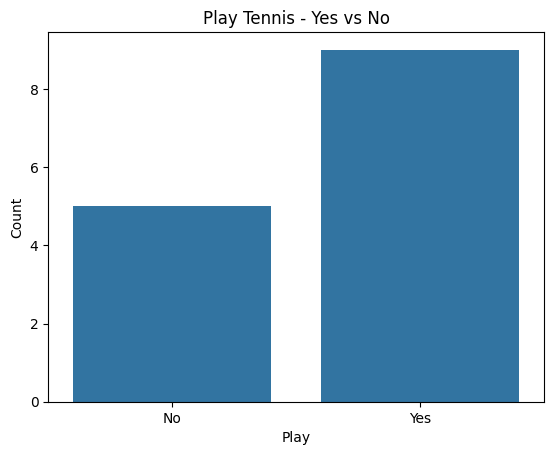

In [ ]:
sns.countplot(x='play', data=df)

plt.title('Play Tennis - Yes vs No')
plt.xlabel('Play')
plt.ylabel('Count')
plt.show()

In [ ]:
for column in df.columns:
    print("\n", column)
    print(df[column].value_counts())


 day
day
D1     1
D2     1
D3     1
D4     1
D5     1
D6     1
D7     1
D8     1
D9     1
D10    1
D11    1
D12    1
D13    1
D14    1
Name: count, dtype: int64

 outlook
outlook
Sunny       5
Rain        5
Overcast    4
Name: count, dtype: int64

 temp
temp
Mild    6
Hot     4
Cool    4
Name: count, dtype: int64

 humidity
humidity
High      7
Normal    7
Name: count, dtype: int64

 wind
wind
Weak      8
Strong    6
Name: count, dtype: int64

 play
play
Yes    9
No     5
Name: count, dtype: int64


In [ ]:
pd.crosstab(df['outlook'], df['play'])

play,No,Yes
outlook,,
Overcast,0,4
Rain,2,3
Sunny,3,2


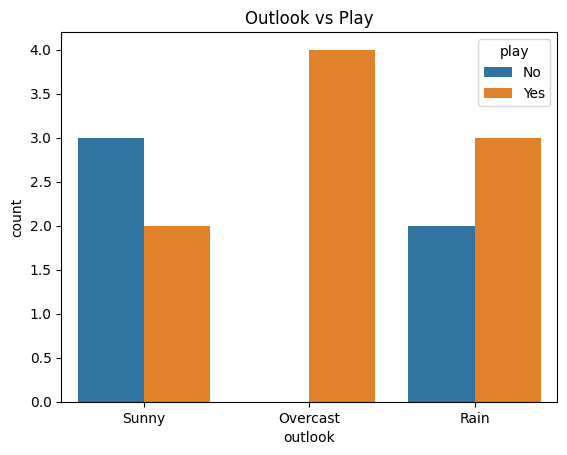

In [ ]:
sns.countplot(x='outlook', hue='play', data=df)

plt.title('Outlook vs Play')
plt.show()

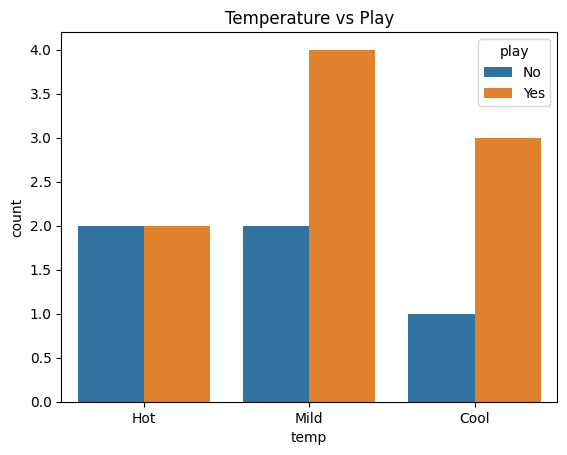

In [ ]:
sns.countplot(x='temp', hue='play', data=df)
plt.title('Temperature vs Play')
plt.show()

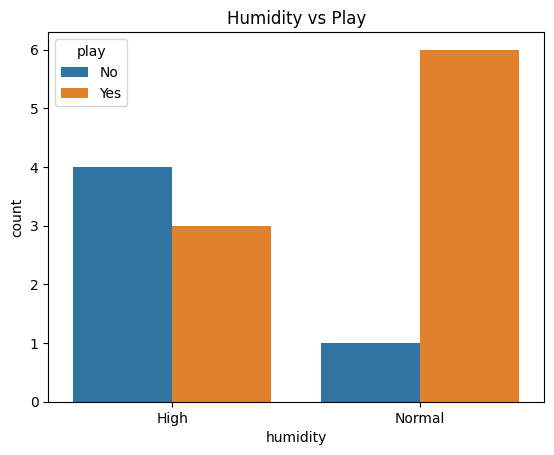

In [ ]:
sns.countplot(x='humidity', hue='play', data=df)
plt.title('Humidity vs Play')
plt.show()

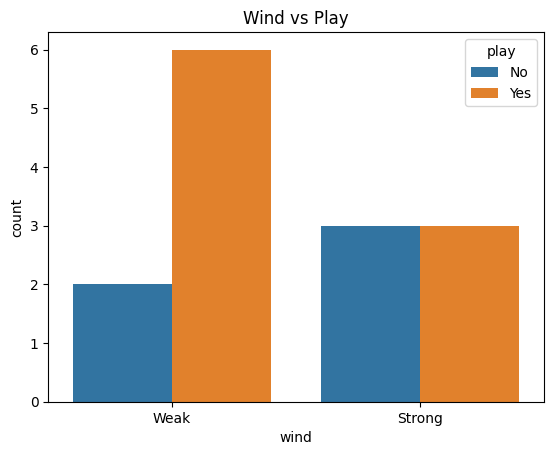

In [ ]:
sns.countplot(x='wind', hue='play', data=df)
plt.title('Wind vs Play')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

encoder = LabelEncoder()

for column in df_ml.columns:
    df_ml[column] = encoder.fit_transform(df_ml[column])

df_ml

,day,outlook,temp,humidity,wind,play
0,0,2,1,0,1,0
1,6,2,1,0,0,0
2,7,0,1,0,1,1
3,8,1,2,0,1,1
4,9,1,0,1,1,1
5,10,1,0,1,0,0
6,11,0,0,1,0,1
7,12,2,2,0,1,0
8,13,2,0,1,1,1
9,1,1,2,1,1,1


In [ ]:
X = df_ml.drop('play', axis=1)
y = df_ml['play']

print("X:")
print(X)

print("\ny:")
print(y)

X:
    day  outlook  temp  humidity  wind
0     0        2     1         0     1
1     6        2     1         0     0
2     7        0     1         0     1
3     8        1     2         0     1
4     9        1     0         1     1
5    10        1     0         1     0
6    11        0     0         1     0
7    12        2     2         0     1
8    13        2     0         1     1
9     1        1     2         1     1
10    2        2     2         1     0
11    3        0     2         0     0
12    4        0     1         1     1
13    5        1     2         0     0

y:
0     0
1     0
2     1
3     1
4     1
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    0
Name: play, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model = DecisionTreeClassifier(criterion='entropy', random_state=42)

model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


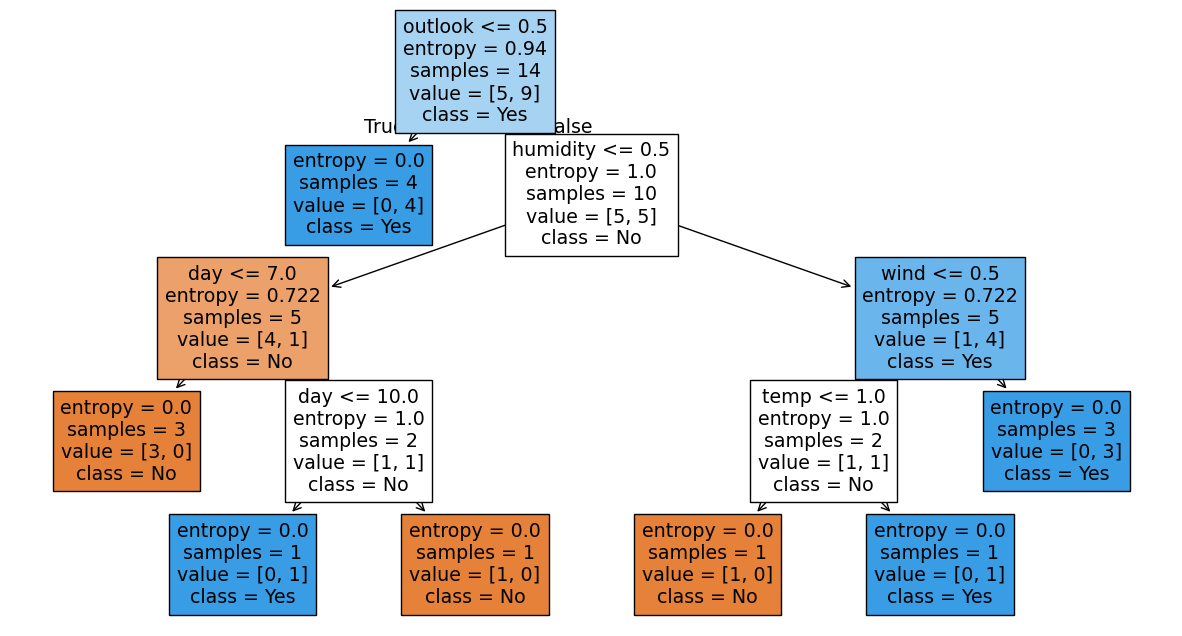

In [ ]:
plt.figure(figsize=(15, 8))

tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()